Setup

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

Data Loader

In [42]:
df = pd.read_csv('../data/apartments_for_rent_classified_10K.csv', sep=';', encoding='cp1252')
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [43]:
#Checking the missing data
df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [44]:
for column in df.columns:
    print(f'Unique values in {column}: ')
    print(df[column].unique())
    print()

Unique values in id: 
[5668626895 5664597177 5668626833 ... 5668643292 5668662559 5509132540]

Unique values in category: 
['housing/rent/apartment' 'housing/rent/home' 'housing/rent/short_term']

Unique values in title: 
['Studio apartment 2nd St NE, Uhland Terrace NE, Washington, DC 20002'
 'Studio apartment 814 Schutte Road'
 'Studio apartment N Scott St, 14th St N, Arlington, VA 22209' ...
 'Six BR 9908 Bentcross Drive' 'One BR in New York NY 10069'
 'Beautiful Lawrenceville Apartment for rent']

Unique values in body: 
['This unit is located at second St NE, Uhland Terrace NE, Washington, DC 20002, Washington, 20002, DCMonthly rental rates range from $790 - $1090We have studio units available for rent'
 'This unit is located at 814 Schutte Road, Evansville, 47712, INMonthly rental rates range from $425 - $445We have studio - 1 beds units available for rent'
 'This unit is located at N Scott St, 14th St N, Arlington, VA 22209, Arlington, 22209, VAMonthly rental rates range from $13

In [45]:
df = df[df['category'] != 'housing/rent/short_term']
df = df.drop(columns=['currency'])
df['category'] = df['category'].replace({
    'housing/rent/apartment': 'apartment',
    'housing/rent/home': 'home'
})


In [46]:
df_clean = df.copy()


In [47]:
(df['price_display'] == 0).sum()

np.int64(0)

In [48]:
df.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

In [49]:
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'fee', 'has_photo', 'pets_allowed', 'price', 'price_display',
       'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude',
       'longitude', 'source', 'time'],
      dtype='object')

In [ ]:
df['body'].str.contains('furnished', case=False, na=False).sum()

np.int64(450)

In [55]:
df['furnished'] = df['body'].str.contains('furnished', case=False, na=False).map({True: 'Yes', False: 'No'})
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,furnished
0,5668626895,apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,No,Thumbnail,NaN,...,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415,No
1,5664597177,apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,No,Thumbnail,NaN,...,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063,No
2,5668626833,apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,No,Thumbnail,NaN,...,Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410,No
3,5659918074,apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,No,Thumbnail,NaN,...,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743,No
4,5668626759,apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,No,Thumbnail,NaN,...,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401,No


In [56]:
df['furnished'].value_counts()

furnished
No     9548
Yes     450
Name: count, dtype: int64

In [62]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.loc[df['furnished'] == 'Yes', 'price'].mean()
df.loc[df['furnished'] == 'No', 'price'].mean()
avg_price =  df.groupby('furnished')['price'].mean()
print(avg_price)

furnished
No     1491.288018
Yes    1383.737778
Name: price, dtype: float64


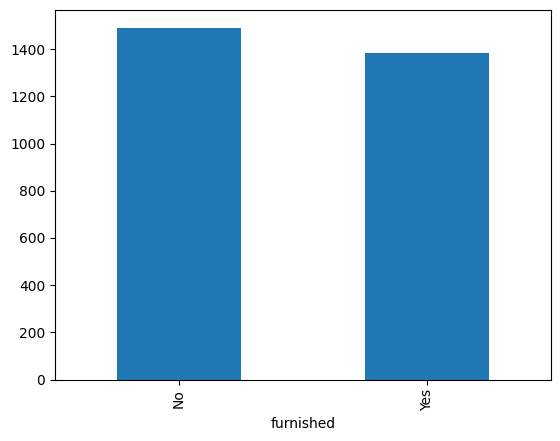

In [63]:
import matplotlib.pyplot as plt

avg_price.plot(kind='bar')

plt.show()

In [66]:
df['pets_allowed'].value_counts(dropna=False)

pets_allowed
Cats,Dogs    5227
NaN          4162
Cats          485
Dogs          124
Name: count, dtype: int64

In [69]:
df.groupby('pets_allowed', dropna=False)['price'].mean()

pets_allowed
Cats         1358.793814
Cats,Dogs    1443.438875
Dogs         2061.016129
NaN          1538.218164
Name: price, dtype: float64

In [71]:
df['pets'] = df['pets_allowed'].notna().map({True: 'Yes', False: 'No'})
avg = df.groupby('pets')['price'].mean()
print(avg)

pets
No     1538.218164
Yes    1449.526388
Name: price, dtype: float64


In [75]:
increase = ((avg['Yes'] - avg['No']) / avg['No']) * 100
print(increase)

-5.765877588953231
